<a href="https://colab.research.google.com/github/PioPio31/AnaliticaDeDatos_Equipo1/blob/main/Practica4_U2/UNIDAD2RegresionLog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Curso: modelos de aprendizaje**

**UNIDAD 2**


---

*   NOMBRE: Montserrat Valdez Escobedo
*   NO CONTROL: 23111475



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DIR = "/content/drive/MyDrive/Analitica_Datos"
os.chdir(DIR)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler, OrdinalEncoder,FunctionTransformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Librerías para la regresión
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, confusion_matrix, precision_score,recall_score,accuracy_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import PolynomialFeatures

---

## **<font color=" #895cf9">Explica brevemente el uso de las librerias del segmento de codigo anterior, haciendo uso de la siguiente tabla</font>**


| Library | Explanation |
|----------|-------------|
| **import numpy as np** | Permite realizar operaciones matemáticas y trabajar con arreglos numéricos de manera eficiente. |
| **import pandas as pd** | Permite trabajar con estructuras de datos como DataFrames, facilitando la lectura, organización, limpieza y análisis de los datos. |
| **import matplotlib.pyplot as plt** | Se utiliza para crear gráficas y visualizar los datos. |
| **import seaborn as sns** | Facilita la creación de gráficas estadísticas, como mapas de calor, diagramas de barras y gráficos de dispersión. |
| **from sklearn.impute import SimpleImputer** | Permite reemplazar valores faltantes utilizando estrategias como la media, mediana o moda. |
| **from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer** | Contiene herramientas para escalar variables numéricas, transformar variables categóricas y aplicar funciones personalizadas durante el preprocesamiento de los datos. |
| **from sklearn.compose import ColumnTransformer, make_column_selector** | Permite aplicar diferentes transformaciones a distintas columnas y seleccionar variables automáticamente según su tipo de dato. |
| **from sklearn.pipeline import make_pipeline** | Permite crear una secuencia ordenada de pasos de preprocesamiento y modelado. |
| **from sklearn.linear_model import LinearRegression** | Implementa el modelo de regresión lineal para realizar predicciones sobre variables numéricas continuas. |
| **from sklearn.linear_model import LogisticRegression** | Implementa el modelo de regresión logística para resolver problemas de clasificación. |
| **from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, precision_score, recall_score, accuracy_score** | Incluye diferentes métricas para evaluar el desempeño de modelos de regresión y clasificación. |
| **from sklearn.decomposition import PCA** | Permite reducir la dimensionalidad del conjunto de datos conservando la mayor cantidad posible de información. |
| **from sklearn.preprocessing import PolynomialFeatures** | Permite generar nuevas características mediante combinaciones y potencias de las variables originales. |







---

In [ ]:
#lectura del .csv con pandas
data_df = pd.read_csv('data.csv')
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [ ]:
#utilice funcion .set_index()
#Guarde los cambios con inplace=True

#-----------------------------------------------------
#Escriba su codigo
data_df.set_index('id',inplace=True)
#-----------------------------------------------------

#-----------------------------------------------------


In [ ]:
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820




1a) Estadísticas descriptivas para todas las variables del dataframe.

In [ ]:
#.describe para variables Numericas
#-----------------------------------------------------
numerical = data_df.select_dtypes(include=np.number)
numerical.describe()
#-----------------------------------------------------

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
#.describe() para variable categoricas
#-----------------------------------------------------
categorical = data_df.select_dtypes(exclude=np.number)
categorical.describe()
#-----------------------------------------------------

,diagnosis
count,569
unique,2
top,B
freq,357


1b) Valores únicos por variable para identificar posibles variables categóricas.

In [ ]:
# Se hace una lista de variables numéricas y otra de categóricas.

#-----------------------------------------------------
num_cols = data_df.select_dtypes(include=np.number).columns.tolist() #para variables numericas
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist() #para variables Categoricas
#-----------------------------------------------------

In [ ]:
# Recuento de cada categoría única en las variables categóricas
data_df[cat_cols].nunique()

,0
diagnosis,2


In [ ]:
# Recuento de cada categoría única en las variables categóricas
data_df[cat_cols].value_counts()

,count
diagnosis,
B,357
M,212


1c) Búsqueda de valores faltantes.

In [ ]:
#Explica cada linea de codigo
print('Número valores faltantes: ') #Imprime el mensaje
for col in data_df.columns: #Recorre cada una de las columnas del dataframe
  valor=sum(data_df[col].isna()) #Cuenta la cantidad de valores faltantes de la columna
  porcentaje=data_df[col].isna().mean()*100 #Calcula el porcentaje de valores faltantes de la columna
  print('{}:{}: porcentaje :{}'.format(col,valor,porcentaje)) #Imprime el nombre de la columna, cantidad y porcentaje de valores faltantes

Número valores faltantes: 
diagnosis:0: porcentaje :0.0
radius_mean:0: porcentaje :0.0
texture_mean:0: porcentaje :0.0
perimeter_mean:0: porcentaje :0.0
area_mean:0: porcentaje :0.0
smoothness_mean:0: porcentaje :0.0
compactness_mean:0: porcentaje :0.0
concavity_mean:0: porcentaje :0.0
concave points_mean:0: porcentaje :0.0
symmetry_mean:0: porcentaje :0.0
fractal_dimension_mean:0: porcentaje :0.0
radius_se:0: porcentaje :0.0
texture_se:0: porcentaje :0.0
perimeter_se:0: porcentaje :0.0
area_se:0: porcentaje :0.0
smoothness_se:0: porcentaje :0.0
compactness_se:0: porcentaje :0.0
concavity_se:0: porcentaje :0.0
concave points_se:0: porcentaje :0.0
symmetry_se:0: porcentaje :0.0
fractal_dimension_se:0: porcentaje :0.0
radius_worst:0: porcentaje :0.0
texture_worst:0: porcentaje :0.0
perimeter_worst:0: porcentaje :0.0
area_worst:0: porcentaje :0.0
smoothness_worst:0: porcentaje :0.0
compactness_worst:0: porcentaje :0.0
concavity_worst:0: porcentaje :0.0
concave points_worst:0: porcentaje :

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

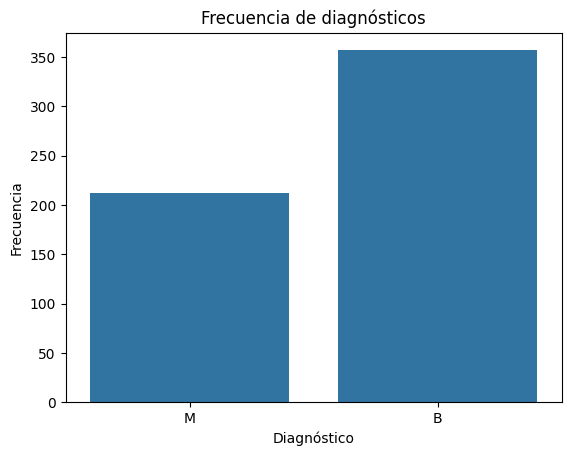

In [ ]:
#utilice sns.countplot()
#-----------------------------------------------------
sns.countplot(x='diagnosis', data=data_df)

plt.title('Frecuencia de diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Frecuencia')

plt.show()
#-----------------------------------------------------

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

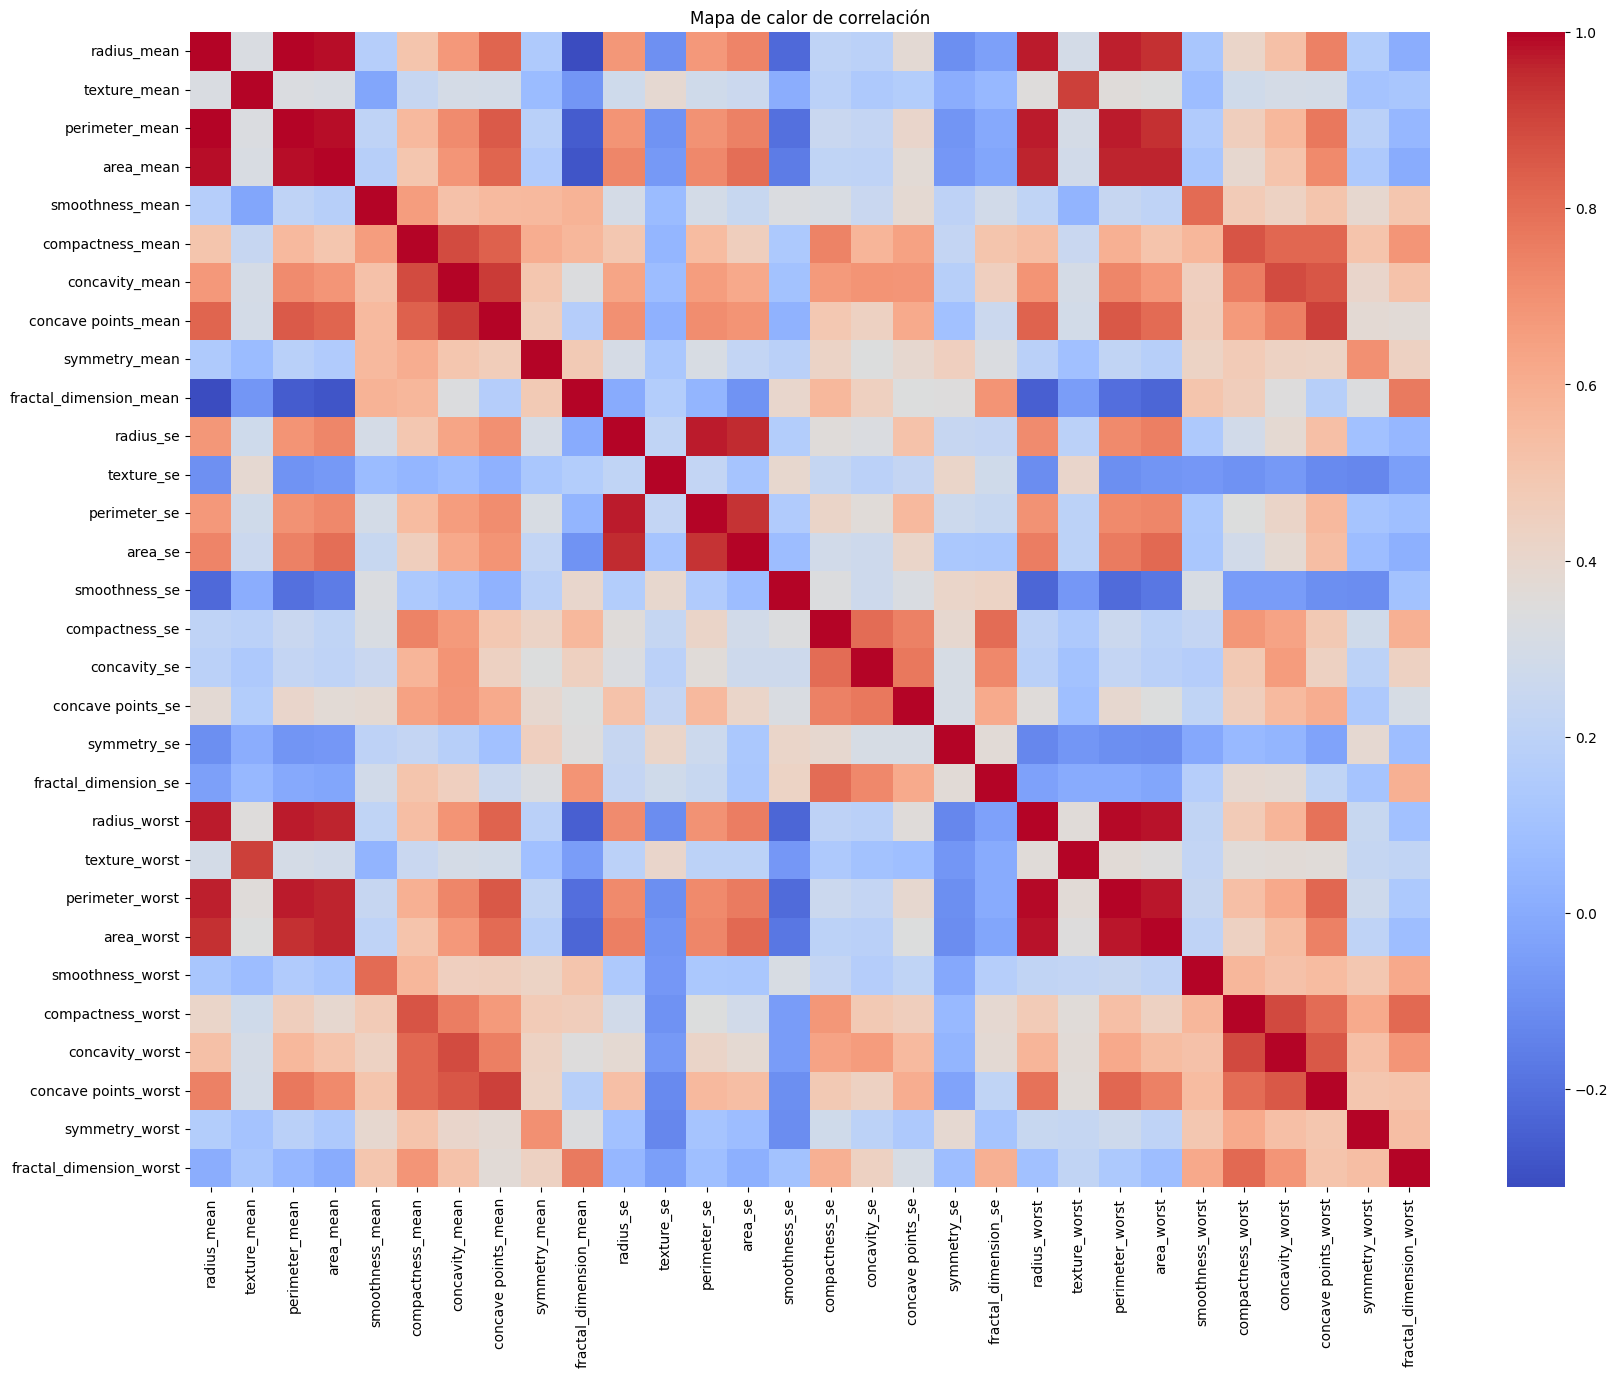

In [ ]:
numeric_df = data_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
# Se calcula la matriz de correlación
corr_matrix = numeric_df.corr()

# Se crea el mapa de calor
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title('Mapa de calor de correlación')
plt.show()
#-----------------------------------------------------

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

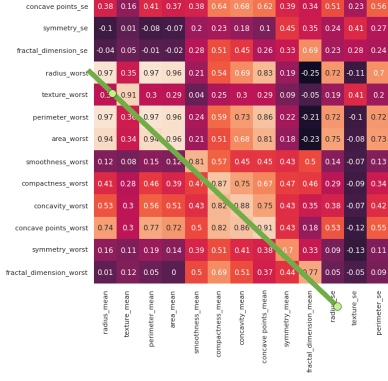

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [ ]:
#-----------------------------------------------------
#Elimine TODAS las columnas _worst
# Se identifican todas las columnas que terminan en _worst
columnas_worst = [col for col in data_df.columns if col.endswith('_worst')]
#-----------------------------------------------------

#para borrar las columnas _worst
nuevo_df = data_df.drop(columns=columnas_worst)

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
nuevo_df = pd.DataFrame(nuevo_df)

nuevo_df
#-----------------------------------------------------

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892


En las graficas de dispersion, los patrones lineales en los diagramas de dispersion se refieren a la relacion entre dos variables que sigue una tendencia aproximadamente en linea recta, ya sea en direccion ascendente o descentende

* **Patron lineal positivo**: Si la linea se inclina hacia arriba (de izquierda a derecha), indica que hay una relacion directa entre las variables: cuando la variable aumenta, la otra tambien lo hace, es decir, CORRELACION POSITIVA

* **Patron lineal negativo**: si la linea se incluna hacia abajo (de izquierda a derecha), indica quue cuando una variable aumenta, la otra disminuye, es decir, CORRELACION NEGATIVA

* **Patron lineal perfecto**, si los puntos siguen una linea recta perfecta, la relacion entre las variables es exactamente lineal, sin desviaciones.


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:

    sns.pairplot(data=nuevo_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])



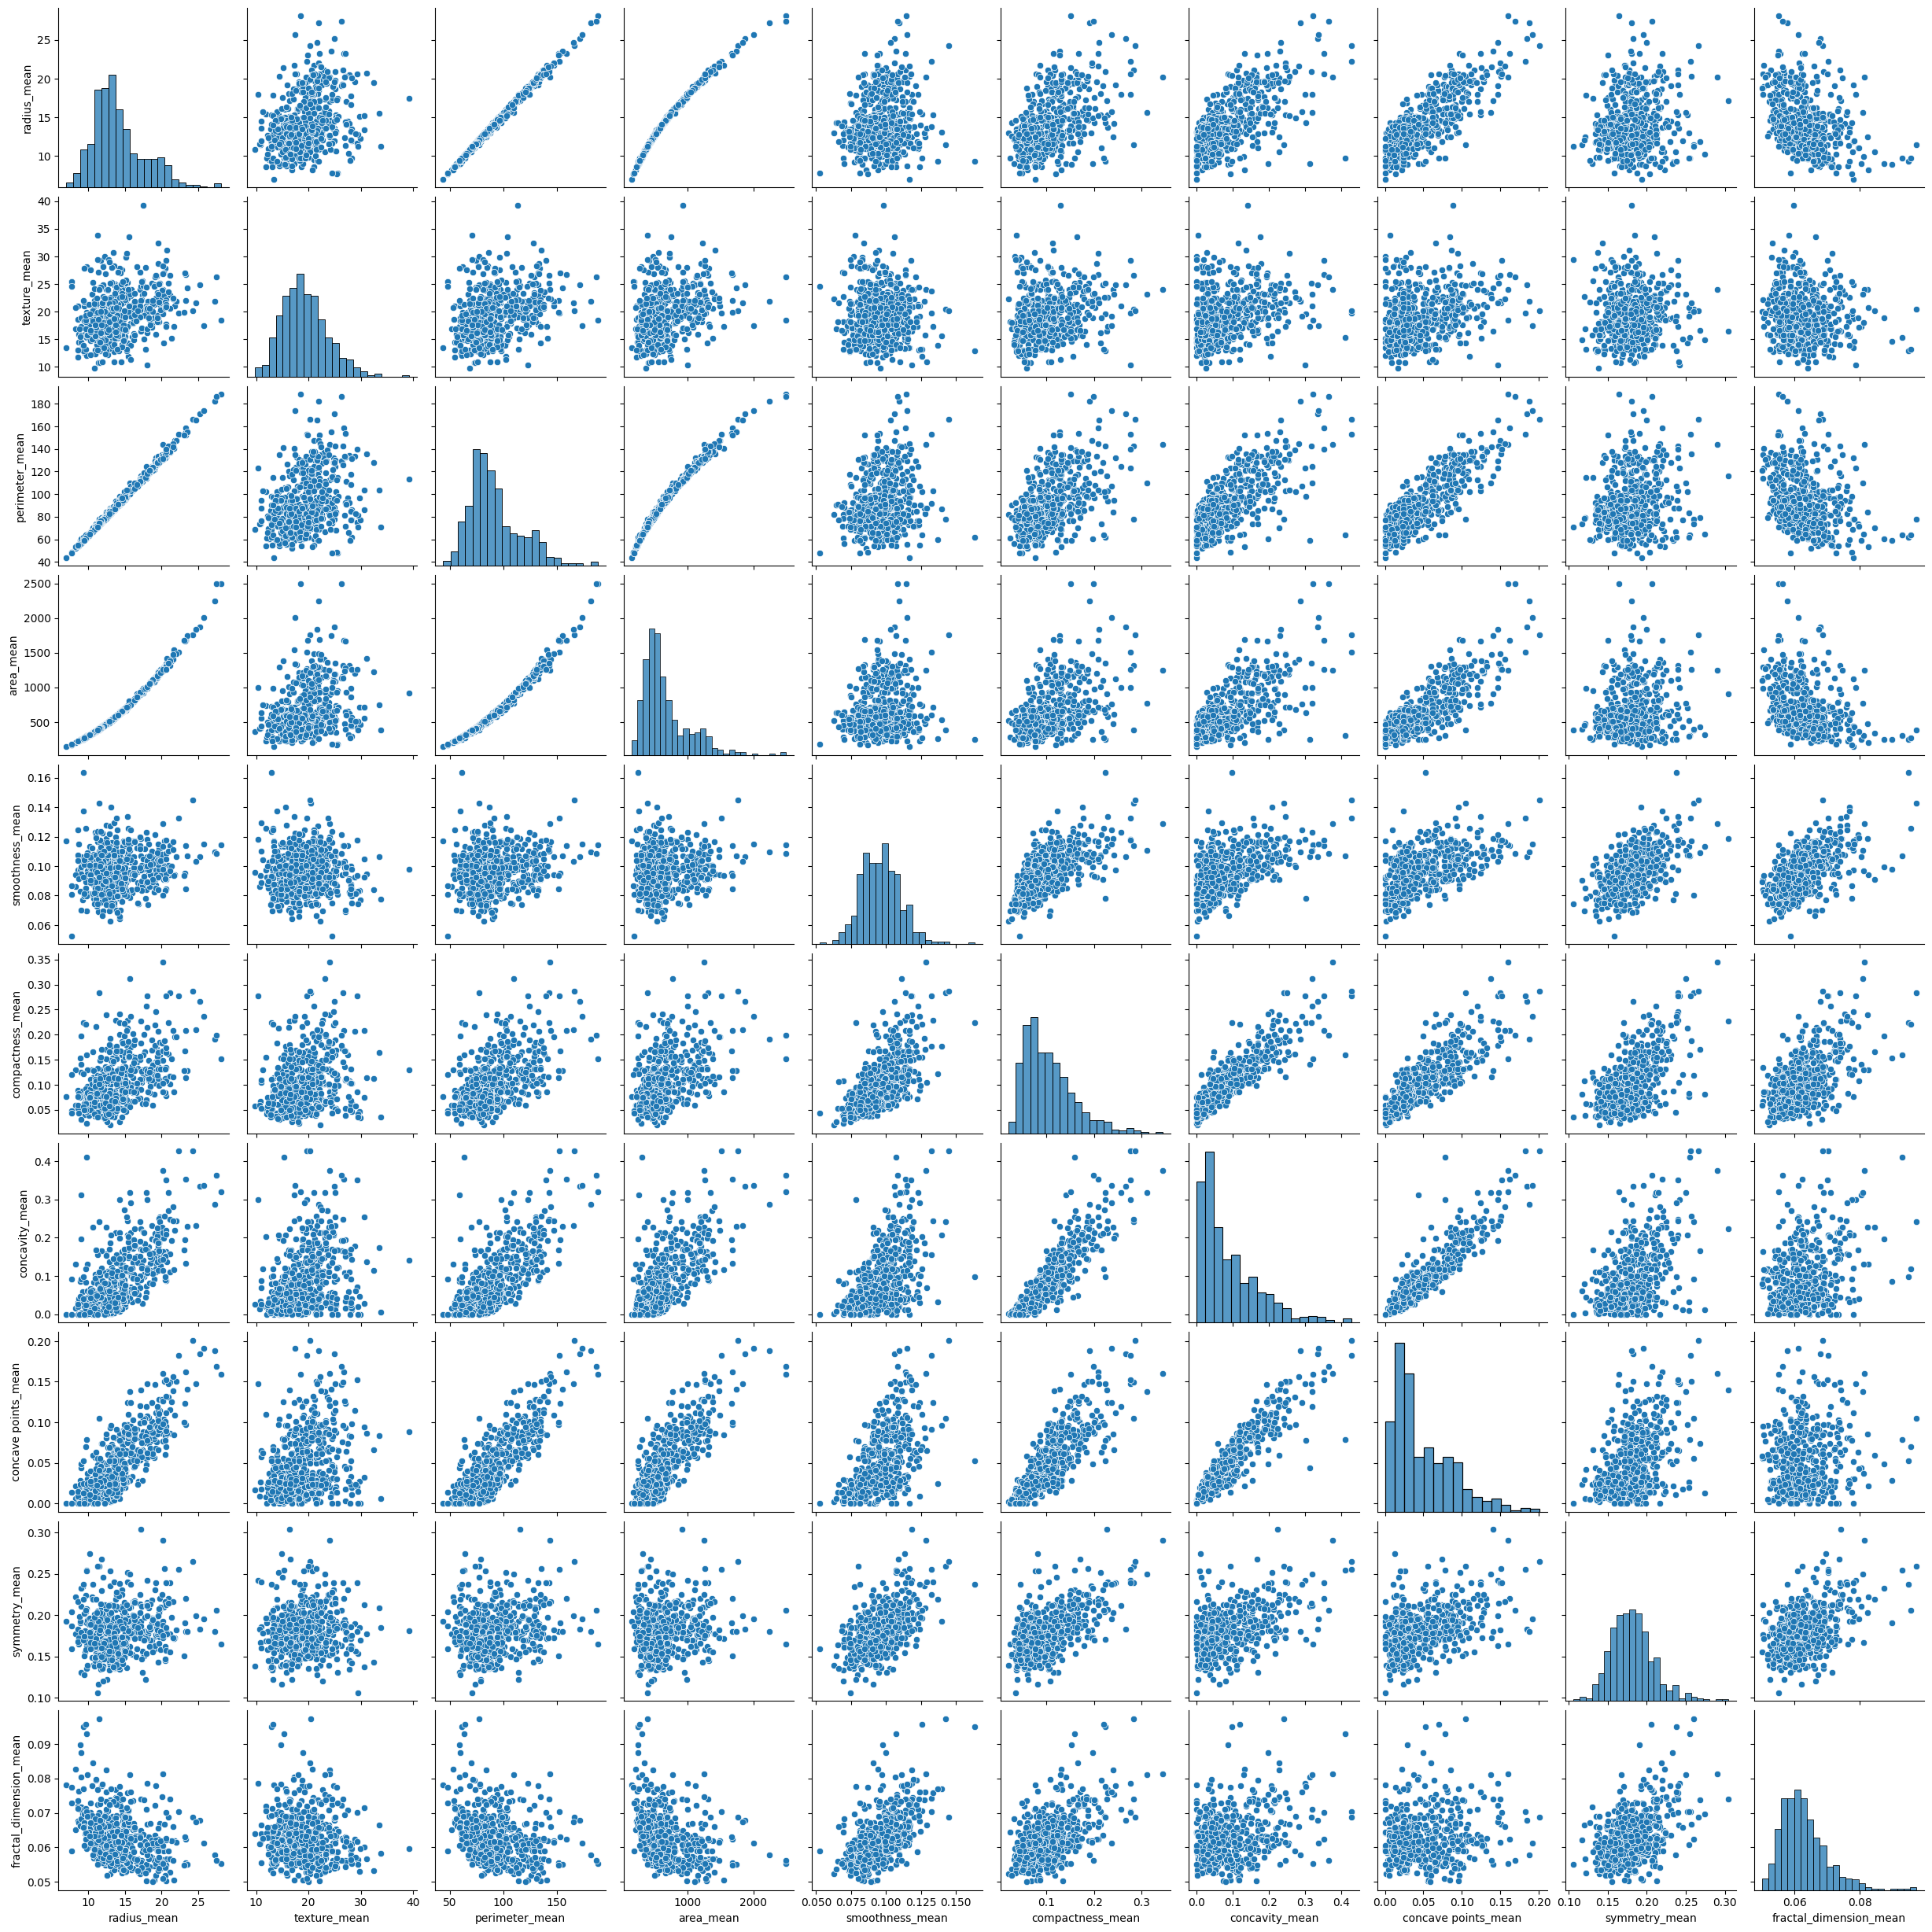

In [ ]:
#-----------------------------------------------------
#Pega aqui el codigo sns.pairplot()
sns.pairplot(data=nuevo_df[['radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean']])

plt.show()
#-----------------------------------------------------

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


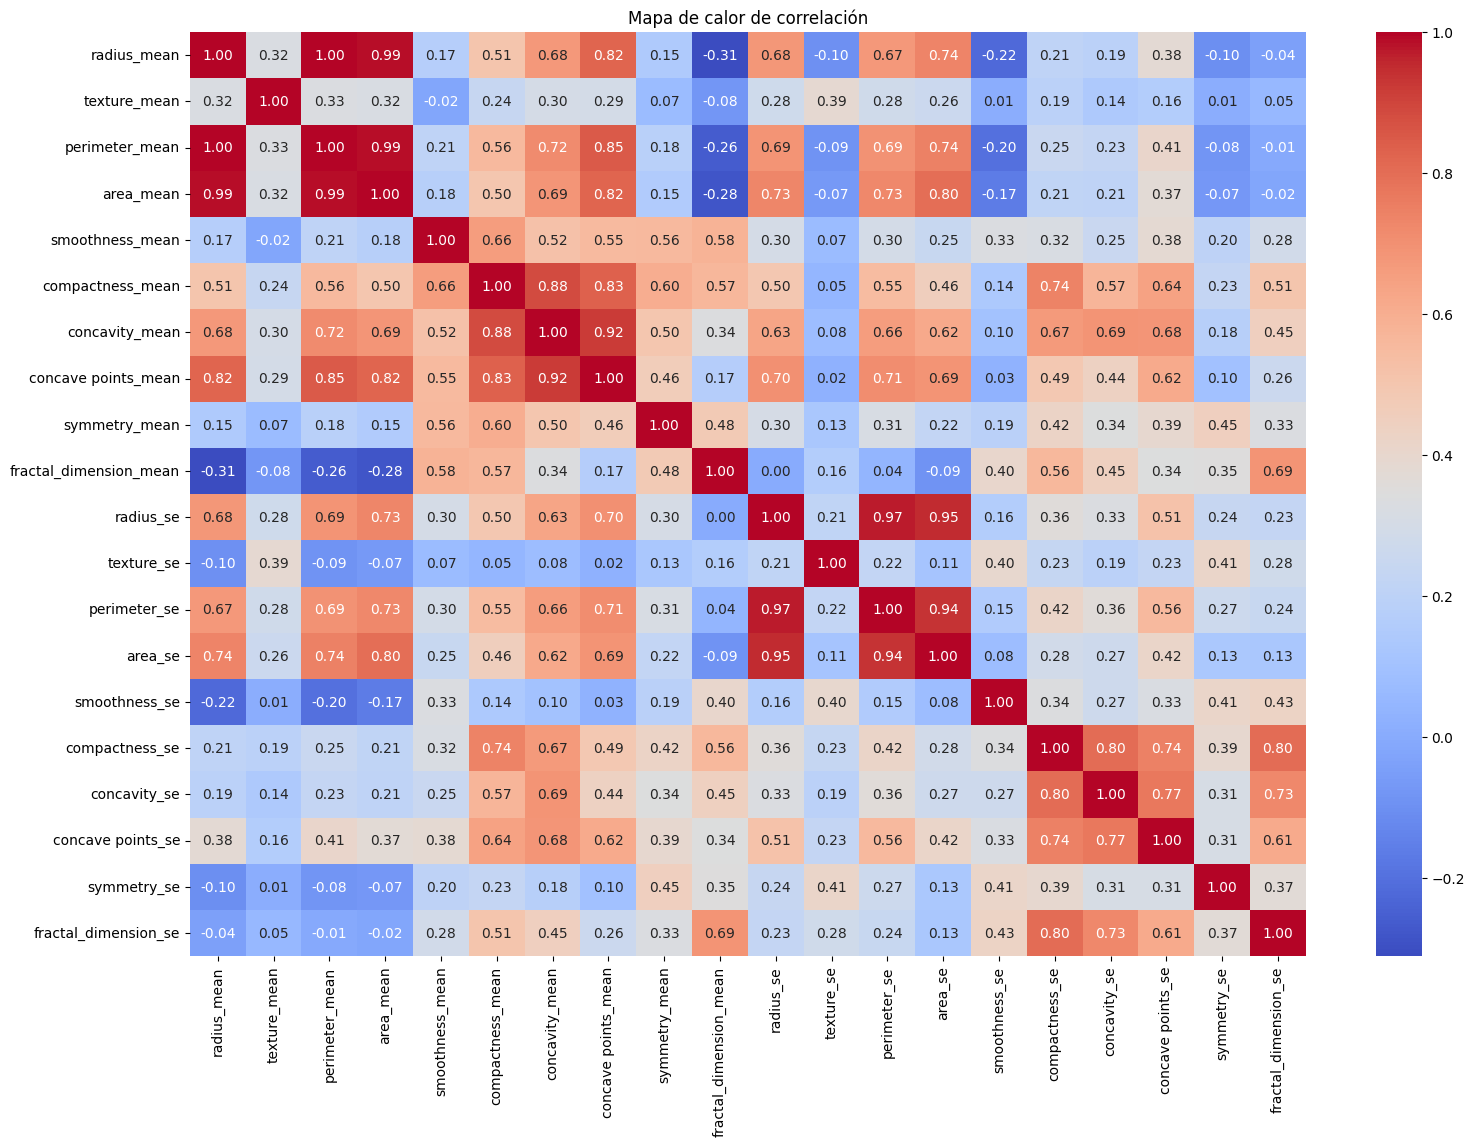

In [ ]:
#-----------------------------------------------------
#Agrega codigo para el mapa de calor
#-----------------------------------------------------
# Se seleccionan únicamente las variables numéricas
numeric_nuevo_df = nuevo_df.select_dtypes(include=[float, int])

# Se calcula la matriz de correlación
corr_matrix = numeric_nuevo_df.corr()

# Se genera el mapa de calor
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Mapa de calor de correlación')
plt.show()

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [ ]:

#-----------------------------------------------------
#escriba TODAS las columnas que seran eliminadas
columnas_a_eliminar = [
    'radius_worst',
    'texture_worst',
    'perimeter_worst',
    'area_worst',
    'smoothness_worst',
    'compactness_worst',
    'concavity_worst',
    'concave points_worst',
    'symmetry_worst',
    'fractal_dimension_worst',
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'concave points_mean',
    'perimeter_se',
    'area_se',
    'concavity_se',
    'concave points_se'
]
#-----------------------------------------------------



#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df = data_df.drop(columns=columnas_a_eliminar)
new_data_df = pd.DataFrame(new_data_df)
#complete linea codigo
new_data_df
#-----------------------------------------------------


,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,
842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239
926682,M,20.13,28.25,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498
926954,M,16.60,28.08,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12, sin contar la columna de indice):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

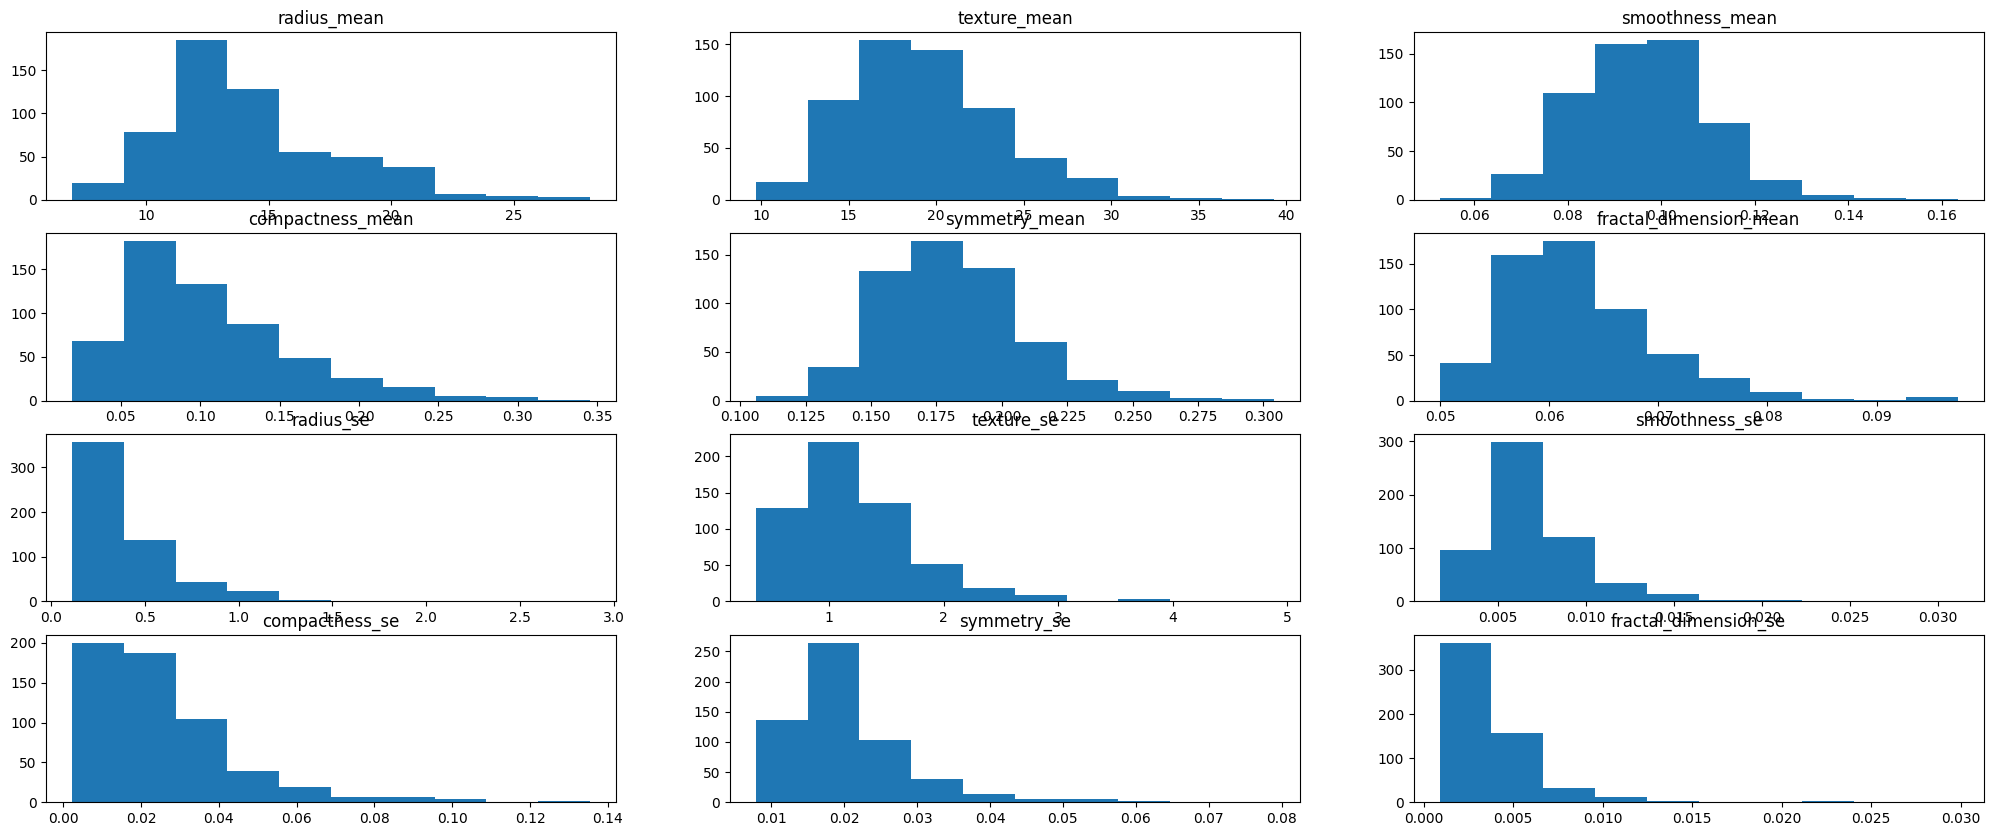

In [ ]:
#EXPLICA CADA LINEA DE CODIGO
skew_cols_df=pd.DataFrame() #Se crea un DataFrame vacío para almacenar las variables con sesgo positivo
# Se crea una figura con 4 filas y 3 columnas para mostrar los histogramas
fig, axes =plt.subplots(4,3, figsize=(25,10)) #25 es el ancho, 10 altura   ---- 4,3 significa que seran  4 filas y 3 columnas
axes = axes.ravel() # Convierte la matriz de ejes en un arreglo de una sola dimensión
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist() # Se obtienen únicamente las columnas numéricas del DataFrame

for col, ax in zip (num_cols, axes): # Se recorre cada columna numérica junto con un eje de la figura
  ax.hist(new_data_df[col])  # Se crea el histograma de la variable
  ax.set(title = f'{col}', xlabel=None) # Se asigna como título el nombre de la variable
  if new_data_df[col].skew()>1 : skew_cols_df[col] =new_data_df[col]  # Si el coeficiente de asimetría es mayor a 1,
 # la variable presenta un sesgo positivo marcado

# Se guardan los nombres de las columnas con sesgo positivo
skew_cols = skew_cols_df.columns.values



In [ ]:
skew_cols

array(['compactness_mean', 'fractal_dimension_mean', 'radius_se',
       'texture_se', 'smoothness_se', 'compactness_se', 'symmetry_se',
       'fractal_dimension_se'], dtype=object)

4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que se encuentren en el intervalo [0,1]


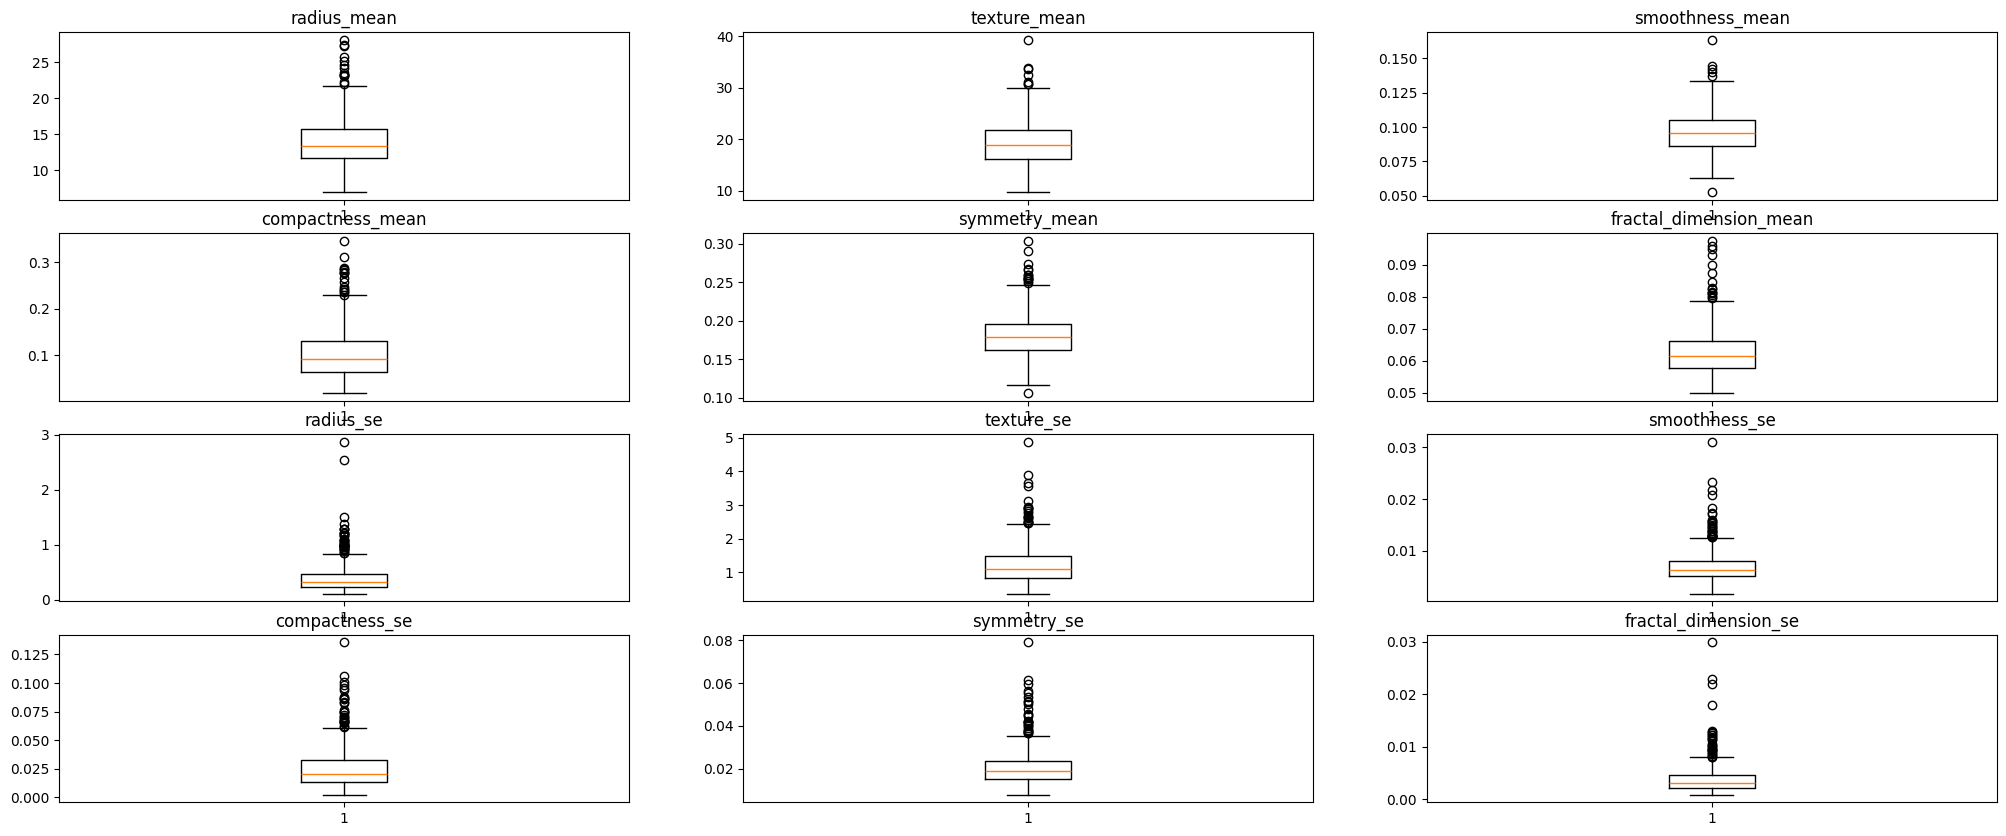

In [ ]:
# Se crea un DataFrame vacío para almacenar las variables que requieren escalamiento
scale_cols_df = pd.DataFrame()

# Se crea una figura con 4 filas y 3 columnas para mostrar los boxplots
fig, axes = plt.subplots(4, 3, figsize=(25, 10))

# Se convierte la matriz de ejes en un arreglo de una sola dimensión
axes = axes.ravel()

# Se recorren las columnas numéricas junto con los ejes
for col, ax in zip(new_data_df[num_cols], axes):

    # Se dibuja el boxplot de cada variable
    ax.boxplot(new_data_df[col])

    # Se coloca el nombre de la variable como título
    ax.set_title(col)

    # Si la variable NO se encuentra completamente en el intervalo [0,1], se guarda para posteriormente aplicarle escalamiento
    if new_data_df[col].min() > 0 or new_data_df[col].max() < 1: scale_cols_df[col] = new_data_df[col]

# Se guardan los nombres de las columnas que requieren escalamiento
scale_cols = scale_cols_df.columns.values



In [ ]:
scale_cols

array(['radius_mean', 'texture_mean', 'radius_se', 'texture_se'],
      dtype=object)

Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [ ]:
data_df = pd.read_csv('data.csv')

#-----------------------------------------------------
#AGREGA LINEA DE CODIGO PARA CONVERTIR COLUMNA "ID" EN INDICE
data_df.set_index('id', inplace=True)
#-----------------------------------------------------

In [ ]:
X = data_df.copy() #Se crea copia del df


#-----------------------------------------------------
#                                  COMPLETA CODIGO
# se elimina variable Categorica "diagnosis" de (X), debido a se sera utilizada como variable de salida (y)
#-----------------------------------------------------
#Especifique la columna que desea eliminar
#Utilice el parametro axis=1, permitira eliminar la columna
#Guarde los cambios agregando el parametro inplace=True

X.drop('diagnosis', axis=1, inplace=True) #Caracteristica / variable Entrada
#-----------------------------------------------------

#-----------------------------------------------------
y = data_df['diagnosis'] #Objetivo /Variable salida
#-----------------------------------------------------

In [ ]:
#Libreria necesaria para realizar la particion del conjunto de datos
from sklearn.model_selection import train_test_split

# Se divide el conjunto en entrenamiento y prueba (80:20), es decir, 80% para Entrenamiento (train) y 20% para Prueba (test)
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1
)

5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO
# Se crea una lista con las variables que presentan alta correlación
columnas_a_eliminar=['radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst','perimeter_mean','area_mean','concavity_mean','concave points_mean','perimeter_se','area_se','concavity_se','concave points_se']

# Se crea un ColumnTransformer para aplicar diferentes transformaciones
# a las columnas del conjunto de datos
preprocessing = ColumnTransformer([
    # Se indica que las columnas de la lista anterior serán eliminadas
    ('num', 'drop', columnas_a_eliminar)]
   ,remainder='passthrough') # Las columnas que no fueron mencionadas se mantienen sin cambios


5c) **Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.**
Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO

# Se crea un pipeline que primero aplica el preprocesamiento
# y después entrena un modelo de regresión logística
logr_model=make_pipeline(preprocessing, LogisticRegression())
# Se entrena el modelo utilizando los datos de entrenamiento
logr_model.fit(Xtrain,ytrain)
# Se realizan predicciones utilizando los datos de prueba
predictions=logr_model.predict(Xtest)

# Se muestra la matriz de confusión.
# B se considera la clase negativa y M la clase positiva
print('matriz de confusion 1:\n',confusion_matrix(ytest,predictions,labels=['B','M']))
# Calcula el recall tomando M como clase positiva
print('recall    :\t',recall_score(ytest,predictions,pos_label='M'))
# Calcula la precision tomando M como clase positiva
print('precision :\t',precision_score(ytest,predictions,pos_label='M'))
# Calcula la exactitud total del modelo
print('accurancy :\t',accuracy_score(ytest,predictions))


matriz de confusion 1:
 [[68  4]
 [10 32]]
recall    :	 0.7619047619047619
precision :	 0.8888888888888888
accurancy :	 0.8771929824561403


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

Esto indica que el modelo clasificó correctamente 68 casos benignos y 32 casos malignos. También cometió 4 falsos positivos, es decir, casos benignos que fueron clasificados como malignos, y 10 falsos negativos, correspondientes a casos malignos que fueron clasificados incorrectamente como benignos.

El recall obtenido fue de 0.7619, equivalente aproximadamente al 76.19 %. Esto significa que el modelo logró identificar correctamente alrededor del 76 % de los casos realmente malignos.

La precision fue de 0.8889, aproximadamente 88.89 %, lo que indica que acertó en casi el 89 % de las ocasiones.

El accuracy fue de 0.8772, equivalente aproximadamente al 87.72 %, por lo que el modelo clasificó correctamente cerca del 88 % del total de observaciones del conjunto de prueba.

El modelo presenta un buen nivel de clasificación, especialmente en precisión y exactitud. Sin embargo, el recall es menor, lo que muestra que todavía existen casos malignos que el modelo no logra identificar correctamente. Por esta razón, será importante evaluar si las transformaciones y el escalamiento aplicados en el siguiente modelo permiten mejorar especialmente la detección de los casos malignos.

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO
# Se crea un nuevo transformador que aplicará diferentes
# operaciones a distintos grupos de variables
preprocessing2 = ColumnTransformer([
    # Se eliminan las columnas altamente correlacionadas
    ('num0','drop', columnas_a_eliminar),
    # Se aplica raíz cuadrada a las variables que presentan sesgo positivo
    ('num1',FunctionTransformer(np.sqrt),skew_cols),
    # Se aplica escalamiento MinMax a las variables seleccionadas
    ('num2',MinMaxScaler(),scale_cols)
  ],remainder='passthrough')

6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [ ]:
#ESCRIBA CODIGO AQUI
# Se crea el segundo modelo mediante un pipeline
logr_model2 = make_pipeline(preprocessing2, LogisticRegression())

# Se entrena el modelo con el conjunto de entrenamiento
logr_model2.fit(Xtrain, ytrain)

# Se realizan las predicciones sobre el conjunto de prueba
predictions2 = logr_model2.predict(Xtest)

# Se muestra la matriz de confusión.
# B se considera la clase negativa y M la clase positiva
print('matriz de confusion 1:\n',confusion_matrix(ytest,predictions2,labels=['B','M']))
# Calcula el recall tomando M como clase positiva
print('recall    :\t',recall_score(ytest,predictions2,pos_label='M'))
# Calcula la precision tomando M como clase positiva
print('precision :\t',precision_score(ytest,predictions2,pos_label='M'))
# Calcula la exactitud total del modelo
print('accurancy :\t',accuracy_score(ytest,predictions2))

matriz de confusion 1:
 [[72  0]
 [11 31]]
recall    :	 0.7380952380952381
precision :	 1.0
accurancy :	 0.9035087719298246


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

Esto indica que el modelo clasificó correctamente 72 casos benignos y 31 casos malignos. Además, no presentó falsos positivos, ya que ningún caso benigno fue clasificado incorrectamente como maligno. Sin embargo, se obtuvieron 11 falsos negativos.

El recall fue de 0.7381, equivalente aproximadamente al 73.81 %. Esto significa que el modelo logró identificar correctamente alrededor del 74 % de los casos realmente malignos.

La precision fue de 1.0, equivalente al 100 %. Esto indica que todos los casos que el modelo clasificó como malignos realmente pertenecían a esta categoría.
El accuracy fue de 0.9035, equivalente aproximadamente al 90.35 %, por lo que el modelo clasificó correctamente poco más del 90 % del total de observaciones.

Al comparar este segundo modelo con el modelo baseline, se observa una mejora en el accuracy, que pasó de aproximadamente 87.72 % a 90.35 %, y en la precision, que aumentó de 88.89 % a 100 %. Sin embargo, el recall disminuyó de aproximadamente 76.19 % a 73.81 %, lo que significa que el segundo modelo dejó sin detectar un caso maligno adicional.

En general, el segundo modelo presenta una mayor exactitud global y una precisión perfecta para los casos clasificados como malignos, aunque su capacidad para detectar todos los casos malignos disminuyó ligeramente.

<font color=" ORANGE">CONCLUSION DE LA PRACTICA

En esta práctica se desarrollaron y compararon dos modelos de regresión logística para clasificar los diagnósticos en benignos y malignos. Antes de construir los modelos, se realizó un análisis exploratorio de los datos, se identificaron variables altamente correlacionadas, se analizaron distribuciones y se seleccionaron variables que requerían transformación o escalamiento.

El primer modelo funcionó como referencia inicial y obtuvo un buen desempeño general. Posteriormente, se construyó un segundo modelo incorporando transformaciones para variables con sesgo positivo y escalamiento mediante MinMaxScaler.

Los resultados mostraron que el segundo modelo mejoró la precisión y la exactitud global, alcanzando un accuracy aproximado de 90.35 % y una precision de 100 %. Sin embargo, el recall disminuyó ligeramente, por lo que el segundo modelo detectó una proporción menor de casos malignos.

Esto permite concluir que el preprocesamiento puede mejorar algunas métricas del modelo, pero no necesariamente todas al mismo tiempo. Por ello, es importante analizar varias métricas y no únicamente el accuracy, especialmente en problemas de clasificación donde los falsos negativos pueden tener una gran importancia.